In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Load the dataset

In [2]:
df = pd.read_csv("../Dataset/S2_chest_data.csv")

### Filter the data

In [3]:
accept_label = [1, 2, 3, 4]
df = df[df["Label"].isin(accept_label)]

### Categorize the data

In [4]:
nStr = [1, 3, 4]
def apply_target(label):
    if label == 2:
        return 1
    elif label in nStr:
        return 0
    else:
        return "unknown"

df["Label"] = df["Label"].apply(apply_target)

df.head(2)

,ACC_X,ACC_Y,ACC_Z,ECG,EMG,EDA,Temp,Resp,Label
214583,0.8914,-0.1102,-0.2576,0.030945,-0.003708,5.710983,29.083618,1.191711,0
214584,0.8926,-0.1086,-0.2544,0.033646,-0.014145,5.719376,29.122437,1.139832,0


### Transform the EMG feature

In [5]:
df["EMG"] = df["EMG"].abs()

### Removing the outliers

In [6]:
def IQR_outlier(feature, dataset):
    while True:
        Q1 = dataset[feature].quantile(0.25)
        Q3 = dataset[feature].quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        new_df = dataset[(dataset[feature] >= lower) & (dataset[feature] <= upper)]

        # stop when no more rows are removed
        if len(new_df) == len(dataset):
            break

        dataset = new_df
    return dataset

def remove_outliers(df, feature_array):
    for feature in feature_array:
        print(f">----- removing outliers from feature: {feature} -----<")
        df = IQR_outlier(feature, df)
    return df

In [7]:
feature_array = ['ACC_X', 'ACC_Y', 'ACC_Z', 'EDA', 'Temp', 'Resp']
df = remove_outliers(df, feature_array)

>----- removing outliers from feature: ACC_X -----<
>----- removing outliers from feature: ACC_Y -----<
>----- removing outliers from feature: ACC_Z -----<
>----- removing outliers from feature: EDA -----<
>----- removing outliers from feature: Temp -----<
>----- removing outliers from feature: Resp -----<


### Plot the graph

In [8]:
# scattered plot
def scatter_plot(df, columns):
    plt.scatter(range(len(df)), df[columns], s=1)
    plt.title("Scatter plot of " + columns)
    plt.show()

def box_plot(df, columns):
    plt.boxplot(df[columns])
    plt.title(f"Box plot of {columns}")
    plt.show()

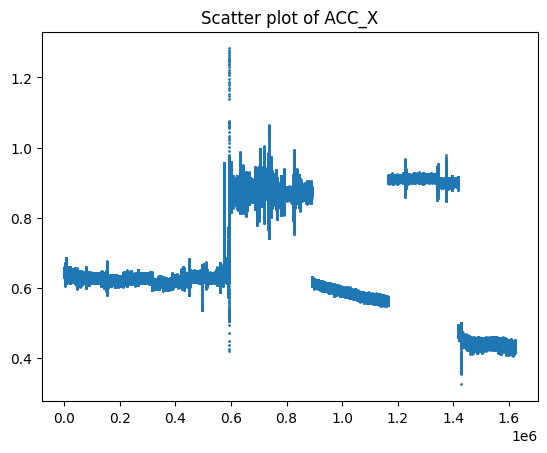

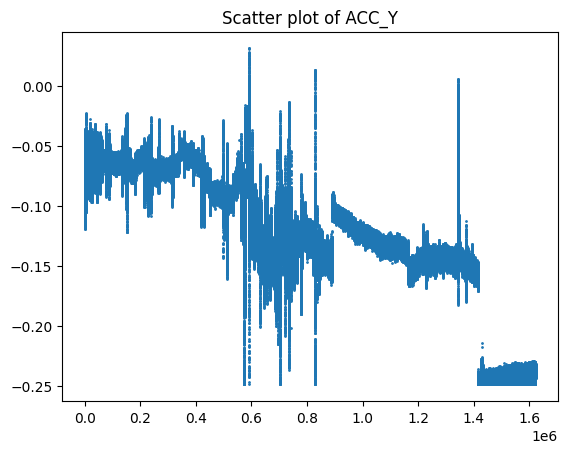

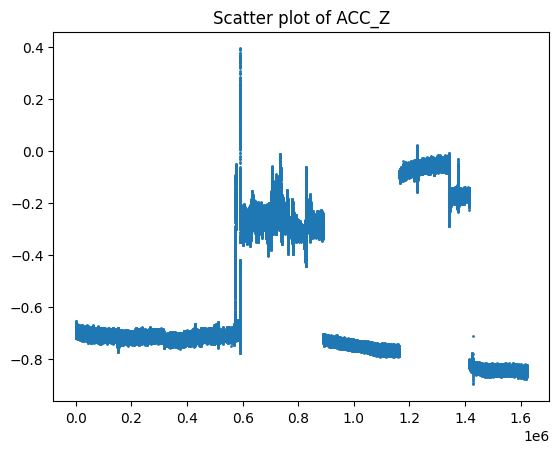

In [9]:
scatter_plot(df=df, columns='ACC_X')
scatter_plot(df=df, columns='ACC_Y')
scatter_plot(df=df, columns='ACC_Z')

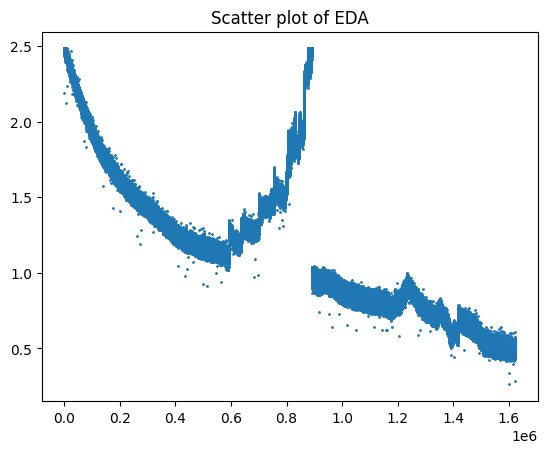

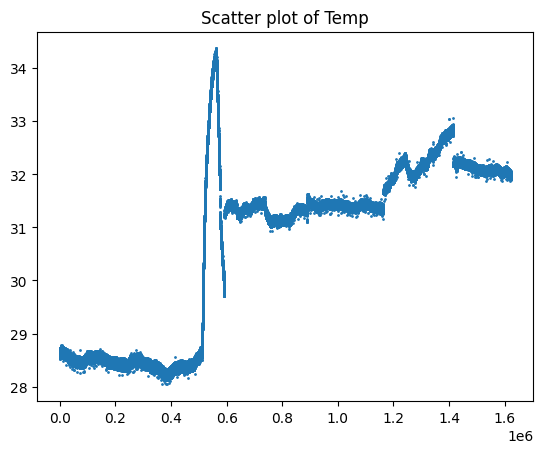

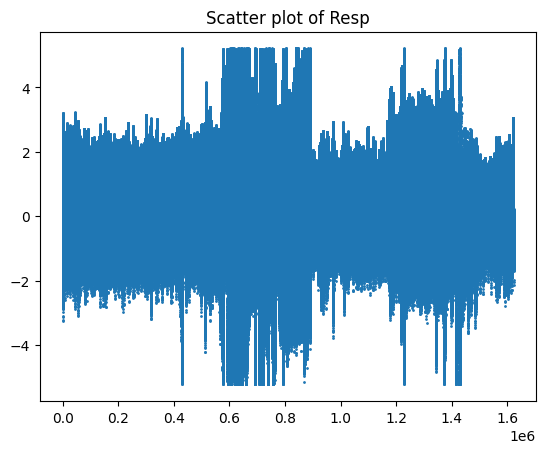

In [10]:
scatter_plot(df=df, columns='EDA')
scatter_plot(df=df, columns='Temp')
scatter_plot(df=df, columns='Resp')

### Handle outlier of EMG

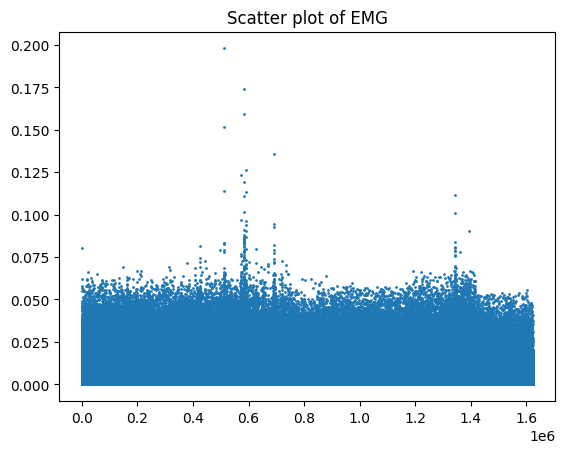

In [11]:
scatter_plot(df, "EMG")

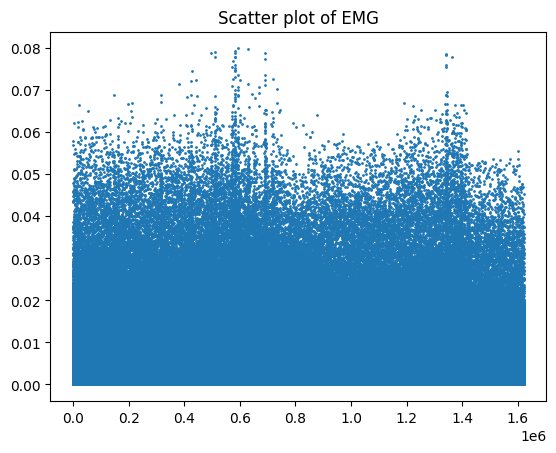

In [12]:
df = df[df["EMG"] < 0.08]
scatter_plot(df, "EMG")

Final Summary 

In [13]:
df.describe()

,ACC_X,ACC_Y,ACC_Z,ECG,EMG,EDA,Temp,Resp,Label
count,1.622321e+06,1.622321e+06,1.622321e+06,1.622321e+06,1.622321e+06,1.622321e+06,1.622321e+06,1.622321e+06,1.622321e+06
mean,6.865531e-01,-1.244320e-01,-5.574829e-01,7.705182e-04,7.127131e-03,1.164218e+00,3.066769e+01,-4.598136e-02,1.838335e-01
std,1.587794e-01,5.553048e-02,2.731173e-01,1.343601e-01,6.762679e-03,4.887860e-01,1.625670e+00,1.709717e+00,3.873485e-01
min,3.246000e-01,-2.488000e-01,-8.982000e-01,-8.248444e-01,0.000000e+00,2.632141e-01,2.804526e+01,-5.216980e+00,0.000000e+00
25%,5.976000e-01,-1.450000e-01,-7.410000e-01,-5.763245e-02,2.380371e-03,7.751465e-01,2.848459e+01,-1.307678e+00,0.000000e+00
50%,6.270000e-01,-1.256000e-01,-7.118000e-01,1.130676e-02,5.264282e-03,1.150131e+00,3.132230e+01,-2.456665e-01,0.000000e+00
75%,8.778000e-01,-7.220000e-02,-2.750000e-01,4.476929e-02,9.841919e-03,1.467514e+00,3.199145e+01,1.298523e+00,0.000000e+00
max,1.283000e+00,3.139997e-02,3.954000e-01,1.068787e+00,7.992554e-02,2.483749e+00,3.437039e+01,5.207825e+00,1.000000e+00


### Balancing the dataset

In [ ]:
df['Label'].value_counts()

Label
0    1324084
1     298237
Name: count, dtype: int64

In [ ]:
from sklearn.utils import resample

# majority class
low_stress = df[df["Label"] == 0]

# minority class
high_stress = df[df["Label"] == 1]

low_downsampled = resample(
    low_stress,
    replace=False,
    n_samples=len(high_stress),
    random_state=42
)

df = pd.concat([low_downsampled, high_stress]).sample(frac=1)

df['Label'].value_counts()

Label
0    298237
1    298237
Name: count, dtype: int64

### Save the preprocessed data

In [16]:
df["Label"].value_counts()

Label
0    298237
1    298237
Name: count, dtype: int64

In [17]:
df.to_csv("../Dataset/preprocessed_data.csv", index=False)